In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler, LabelEncoder


#### **Phase 1: Data Collection and Exploratory Data Analysis (EDA)**

**Step 1 - Data Import and Preprocessing**

1. Load `Global_Pollution_Analysis.csv`
2. Handle missing / inconsistent values
3. Scale pollution indices + encode Country / Year



In [7]:
df = pd.read_csv('Global_Pollution_Analysis.csv')
df.head()


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [8]:
df.columns


Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
       'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)',
       'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)'],
      dtype='str')

In [9]:
# rename cols so they are easier to type
df = df.rename(columns={
    'Industrial_Waste (in tons)': 'Industrial_Waste',
    'Energy_Recovered (in GWh)': 'Energy_Recovered',
    'CO2_Emissions (in MT)': 'CO2_Emissions',
    'Renewable_Energy (%)': 'Renewable_Energy',
    'Plastic_Waste_Produced (in tons)': 'Plastic_Waste',
    'Energy_Consumption_Per_Capita (in MWh)': 'Energy_Per_Capita',
    'Population (in millions)': 'Population',
    'GDP_Per_Capita (in USD)': 'GDP_Per_Capita'
})
df.head()


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste,Energy_Recovered,CO2_Emissions,Renewable_Energy,Plastic_Waste,Energy_Per_Capita,Population,GDP_Per_Capita
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [10]:
df.isna().sum()


Country                  0
Year                     0
Air_Pollution_Index      0
Water_Pollution_Index    0
Soil_Pollution_Index     0
Industrial_Waste         0
Energy_Recovered         0
CO2_Emissions            0
Renewable_Energy         0
Plastic_Waste            0
Energy_Per_Capita        0
Population               0
GDP_Per_Capita           0
dtype: int64

In [11]:
df.info()
print('\nunique countries:', df['Country'].nunique())
print('years:', sorted(df['Year'].unique()))


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                200 non-null    str    
 1   Year                   200 non-null    int64  
 2   Air_Pollution_Index    200 non-null    float64
 3   Water_Pollution_Index  200 non-null    float64
 4   Soil_Pollution_Index   200 non-null    float64
 5   Industrial_Waste       200 non-null    float64
 6   Energy_Recovered       200 non-null    float64
 7   CO2_Emissions          200 non-null    float64
 8   Renewable_Energy       200 non-null    float64
 9   Plastic_Waste          200 non-null    float64
 10  Energy_Per_Capita      200 non-null    float64
 11  Population             200 non-null    float64
 12  GDP_Per_Capita         200 non-null    float64
dtypes: float64(11), int64(1), str(1)
memory usage: 22.5 KB

unique countries: 175
years: [np.int64(2000), np.int64(2001), np.

In [12]:
# no missing values here, but if there were we could fill with median
# just keeping a simple fillna for practice
num_cols = df.select_dtypes(include=['number']).columns.tolist()
for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

print('missing after fill:', df.isna().sum().sum())
print('num cols:', num_cols)


missing after fill: 0
num cols: ['Year', 'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Industrial_Waste', 'Energy_Recovered', 'CO2_Emissions', 'Renewable_Energy', 'Plastic_Waste', 'Energy_Per_Capita', 'Population', 'GDP_Per_Capita']


In [13]:
# encode Country (too many for one-hot with only 200 rows)
le_country = LabelEncoder()
df['Country_Encoded'] = le_country.fit_transform(df['Country'])

# Year can stay numeric for trends / model; also keep a label encoded version
le_year = LabelEncoder()
df['Year_Encoded'] = le_year.fit_transform(df['Year'].astype(str))

# scale pollution indices (air, water, soil)
scaler_poll = StandardScaler()
poll_cols = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
df[['Air_Scaled', 'Water_Scaled', 'Soil_Scaled']] = scaler_poll.fit_transform(df[poll_cols])

df[['Country','Year','Country_Encoded','Year_Encoded'] + poll_cols + ['Air_Scaled','Water_Scaled','Soil_Scaled']].head()


,Country,Year,Country_Encoded,Year_Encoded,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Air_Scaled,Water_Scaled,Soil_Scaled
0,Hungary,2005,77,5,272.70,124.27,51.95,1.376167,0.193880,-0.619764
1,Singapore,2001,147,1,86.72,60.34,117.22,-1.403578,-1.153098,1.028744
2,Romania,2016,136,16,91.59,83.36,121.72,-1.330788,-0.668076,1.142400
3,Cook Islands,2018,38,18,280.61,67.16,93.58,1.494394,-1.009403,0.431675
4,Djibouti,2008,46,8,179.16,127.53,121.55,-0.021926,0.262567,1.138106


**Step 2 - Exploratory Data Analysis (EDA)**

Descriptive stats, correlation heatmap, bar/line/box plots for pollution trends.



In [14]:
# descriptive stats for key pollution / energy cols
key_cols = ['CO2_Emissions', 'Industrial_Waste', 'Air_Pollution_Index',
            'Water_Pollution_Index', 'Soil_Pollution_Index', 'Energy_Recovered']
print(df[key_cols].describe())
print('\nmedian:\n', df[key_cols].median())
print('\nvariance:\n', df[key_cols].var())


       CO2_Emissions  Industrial_Waste  Air_Pollution_Index  \
count     200.000000         200.00000            200.00000   
mean       24.878100       52891.68150            180.62695   
std        14.470892       27224.49169             67.07331   
min         1.920000        1019.37000             50.30000   
25%        11.220000       31201.97250            134.97250   
50%        25.355000       55299.15000            183.38500   
75%        38.550000       74805.82500            237.42500   
max        49.690000       99739.36000            297.95000   

       Water_Pollution_Index  Soil_Pollution_Index  Energy_Recovered  
count             200.000000            200.000000        200.000000  
mean              115.068100             76.488550        260.448700  
std                47.580911             39.692727        147.141923  
min                31.130000             11.150000         11.730000  
25%                74.550000             40.895000        118.355000  
50%   

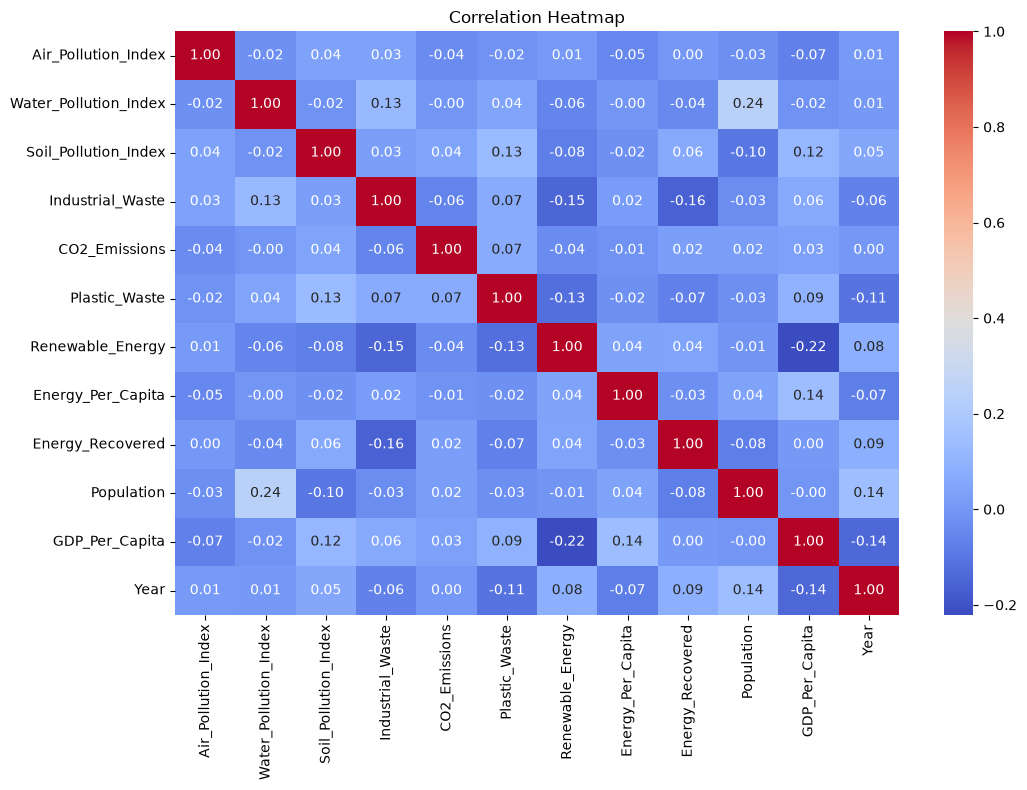

corr with Energy_Recovered:
Energy_Recovered         1.000000
Year                     0.088332
Soil_Pollution_Index     0.064076
Renewable_Energy         0.043533
CO2_Emissions            0.024758
GDP_Per_Capita           0.004535
Air_Pollution_Index      0.002997
Energy_Per_Capita       -0.030284
Water_Pollution_Index   -0.041828
Plastic_Waste           -0.072946
Population              -0.075100
Industrial_Waste        -0.161309
Name: Energy_Recovered, dtype: float64


In [15]:
# correlation heatmap - pollution vs energy etc
corr_cols = ['Air_Pollution_Index','Water_Pollution_Index','Soil_Pollution_Index',
             'Industrial_Waste','CO2_Emissions','Plastic_Waste','Renewable_Energy',
             'Energy_Per_Capita','Energy_Recovered','Population','GDP_Per_Capita','Year']

plt.figure(figsize=(11,8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print('corr with Energy_Recovered:')
print(df[corr_cols].corr()['Energy_Recovered'].sort_values(ascending=False))


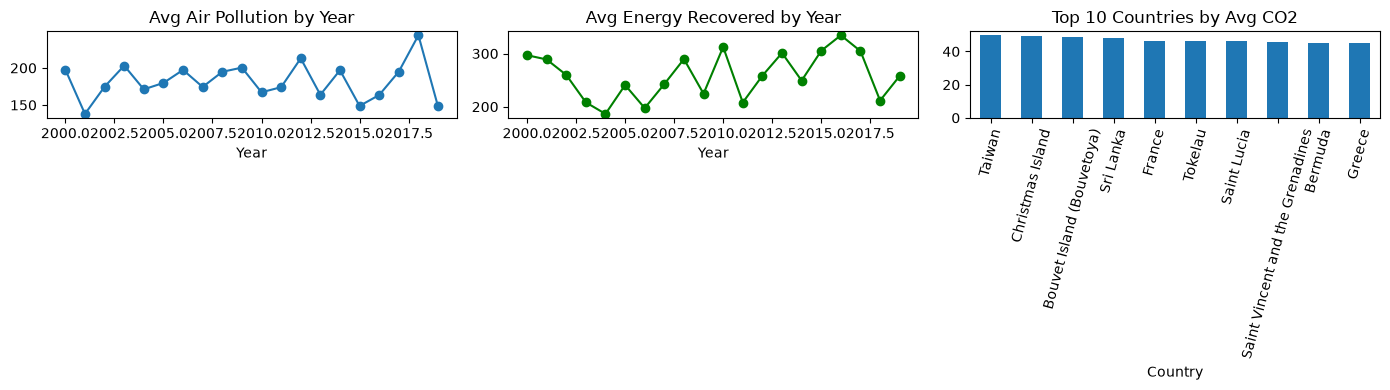

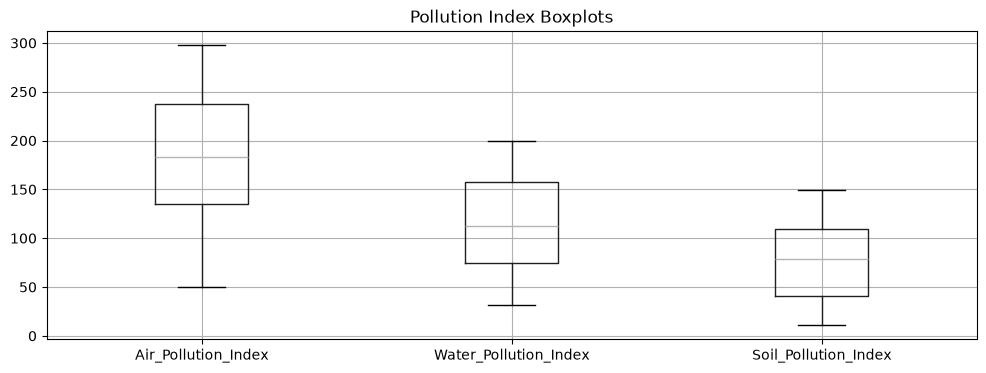

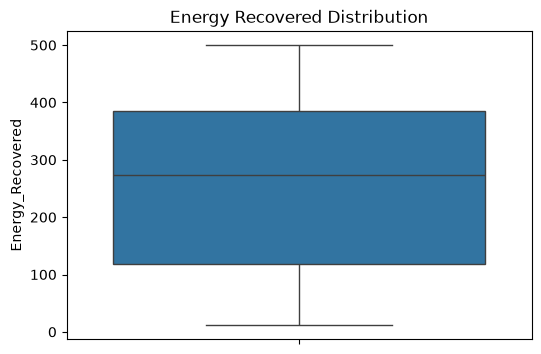

In [16]:
# visualizations - bar, line, box
# yearly average pollution trend
yearly = df.groupby('Year')[['Air_Pollution_Index','CO2_Emissions','Energy_Recovered']].mean().reset_index()

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.plot(yearly['Year'], yearly['Air_Pollution_Index'], marker='o')
plt.title('Avg Air Pollution by Year')
plt.xlabel('Year')

plt.subplot(1,3,2)
plt.plot(yearly['Year'], yearly['Energy_Recovered'], marker='o', color='green')
plt.title('Avg Energy Recovered by Year')
plt.xlabel('Year')

plt.subplot(1,3,3)
top_countries = df.groupby('Country')['CO2_Emissions'].mean().sort_values(ascending=False).head(10)
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Avg CO2')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# boxplots
plt.figure(figsize=(12,4))
df[['Air_Pollution_Index','Water_Pollution_Index','Soil_Pollution_Index']].boxplot()
plt.title('Pollution Index Boxplots')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(y='Energy_Recovered', data=df)
plt.title('Energy Recovered Distribution')
plt.show()


**Step 3 - Feature Engineering**

- Yearly trend features
- Energy consumption per capita (already in data; also make waste/pollution per capita helpers)



In [17]:
# yearly trend: avg energy recovered that year (joined back)
year_energy_trend = df.groupby('Year')['Energy_Recovered'].mean().rename('Year_Avg_Energy_Recovered')
df = df.merge(year_energy_trend, on='Year', how='left')

# pollution composite + yearly air trend
year_air_trend = df.groupby('Year')['Air_Pollution_Index'].mean().rename('Year_Avg_Air_Pollution')
df = df.merge(year_air_trend, on='Year', how='left')

# energy per capita already exists as Energy_Per_Capita
# also create industrial waste per capita (rough feature)
# Population is in millions, waste in tons
df['Industrial_Waste_Per_Capita'] = df['Industrial_Waste'] / (df['Population'] * 1e6)
df['Plastic_Waste_Per_Capita'] = df['Plastic_Waste'] / (df['Population'] * 1e6)

# overall pollution score (simple average of 3 indices)
df['Pollution_Score'] = (
    df['Air_Pollution_Index'] + df['Water_Pollution_Index'] + df['Soil_Pollution_Index']
) / 3

print(df[['Year','Energy_Per_Capita','Year_Avg_Energy_Recovered','Year_Avg_Air_Pollution',
          'Industrial_Waste_Per_Capita','Pollution_Score']].head(8))
print('\nEnergy_Per_Capita describe:')
print(df['Energy_Per_Capita'].describe())


   Year  Energy_Per_Capita  Year_Avg_Energy_Recovered  Year_Avg_Air_Pollution  \
0  2005              12.56                 240.748667              179.756000   
1  2001               5.23                 288.877778              137.964444   
2  2016              13.15                 334.385000              163.471000   
3  2018               0.78                 211.552000              244.112000   
4  2008              12.84                 289.600000              194.782857   
5  2009              18.14                 224.424000              200.440000   
6  2008              16.50                 289.600000              194.782857   
7  2006               2.40                 197.411667              197.326667   

   Industrial_Waste_Per_Capita  Pollution_Score  
0                     0.002245       149.640000  
1                     0.000410        88.093333  
2                     0.000452        98.890000  
3                     0.001104       147.116667  
4                   

#### **Phase 2: Predictive Modeling**

**Step 4 - Linear Regression**

Predict `Energy_Recovered` (GWh) from pollution / waste features.



In [18]:
# linear regression features
feature_cols = [
    'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index',
    'Industrial_Waste', 'CO2_Emissions', 'Plastic_Waste', 'Renewable_Energy',
    'Energy_Per_Capita', 'Population', 'GDP_Per_Capita', 'Year',
    'Country_Encoded', 'Pollution_Score', 'Year_Avg_Air_Pollution',
    'Industrial_Waste_Per_Capita'
]

X = df[feature_cols]
y = df['Energy_Recovered']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred = lr.predict(X_test_s)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Linear Regression - Energy Recovered prediction')
print('MSE:', round(mse, 3))
print('RMSE:', round(np.sqrt(mse), 3))
print('MAE:', round(mae, 3))
print('R2:', round(r2, 3))


Linear Regression - Energy Recovered prediction
MSE: 29239.663
RMSE: 170.996
MAE: 149.924
R2: -0.209


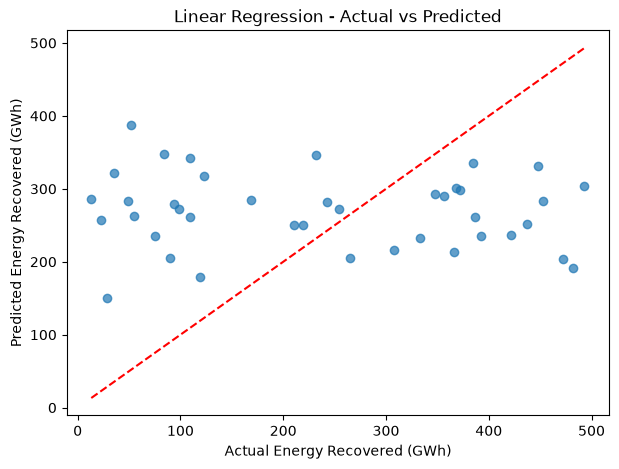

                        feature       coef
8                    Population -27.016598
13       Year_Avg_Air_Pollution -25.229504
10                         Year  19.830681
5                 Plastic_Waste -18.091324
14  Industrial_Waste_Per_Capita -17.451701
3              Industrial_Waste -15.302539
9                GDP_Per_Capita  12.207610
11              Country_Encoded -11.647276
7             Energy_Per_Capita  -7.489744
6              Renewable_Energy  -6.688474


In [19]:
# actual vs predicted
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Energy Recovered (GWh)')
plt.ylabel('Predicted Energy Recovered (GWh)')
plt.title('Linear Regression - Actual vs Predicted')
plt.show()

# rough look at coefficients
coef_df = pd.DataFrame({'feature': feature_cols, 'coef': lr.coef_}).sort_values('coef', key=abs, ascending=False)
print(coef_df.head(10))


**Step 5 - Logistic Regression (Pollution Severity)**

Classify countries/rows into Low / Medium / High pollution using tertiles of `Pollution_Score`.



In [20]:
# pollution severity categories using tertiles
df['Pollution_Level'] = pd.qcut(df['Pollution_Score'], q=3, labels=['Low','Medium','High'])
print(df['Pollution_Level'].value_counts())

# features for classification (dont leak Pollution_Score / components too hard -
# still use air/co2 etc as assignment suggests)
clf_features = [
    'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index',
    'CO2_Emissions', 'Industrial_Waste', 'Plastic_Waste',
    'Renewable_Energy', 'Energy_Per_Capita', 'GDP_Per_Capita',
    'Year', 'Country_Encoded'
]

X_clf = df[clf_features]
y_clf = df['Pollution_Level']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler2 = StandardScaler()
Xc_train_s = scaler2.fit_transform(Xc_train)
Xc_test_s = scaler2.transform(Xc_test)

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(Xc_train_s, yc_train)
yc_pred = log_reg.predict(Xc_test_s)

print('\nAccuracy:', accuracy_score(yc_test, yc_pred))
print('\nClassification Report:')
print(classification_report(yc_test, yc_pred))
print('Confusion Matrix:')
print(confusion_matrix(yc_test, yc_pred, labels=['Low','Medium','High']))


Pollution_Level
Low       67
High      67
Medium    66
Name: count, dtype: int64

Accuracy: 0.975

Classification Report:
              precision    recall  f1-score   support

        High       0.93      1.00      0.97        14
         Low       1.00      1.00      1.00        13
      Medium       1.00      0.92      0.96        13

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.98        40
weighted avg       0.98      0.97      0.97        40

Confusion Matrix:
[[13  0  0]
 [ 0 12  1]
 [ 0  0 14]]


#### **Phase 3: Reporting and Insights**

**Step 6 - Model Evaluation and Comparison**



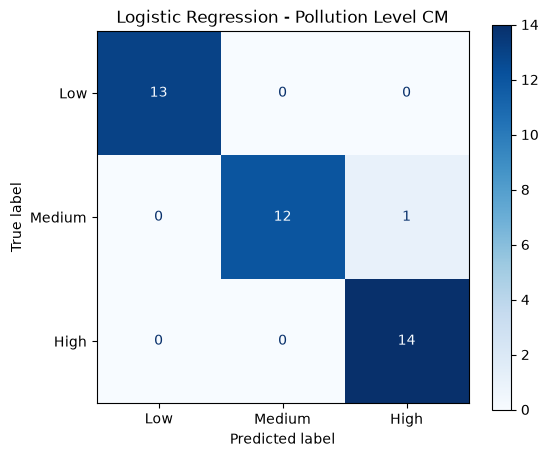

--- Comparison ---
Linear Regression -> predicts Energy_Recovered (GWh)
  R2=-0.209, MAE=149.924, MSE=29239.663
Logistic Regression -> Low / Medium / High pollution
  Accuracy=0.975
LR useful for energy recovery estimate; LogReg for severity tagging.


In [21]:
# confusion matrix plot
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    yc_test, yc_pred, labels=['Low','Medium','High'],
    display_labels=['Low','Medium','High'], ax=ax, cmap='Blues'
)
ax.set_title('Logistic Regression - Pollution Level CM')
plt.show()

print('--- Comparison ---')
print('Linear Regression -> predicts Energy_Recovered (GWh)')
print(f'  R2={r2:.3f}, MAE={mae:.3f}, MSE={mse:.3f}')
print('Logistic Regression -> Low / Medium / High pollution')
print(f'  Accuracy={accuracy_score(yc_test, yc_pred):.3f}')
print('LR useful for energy recovery estimate; LogReg for severity tagging.')


In [22]:
# quick country-level insight: high pollution but low energy recovery
country_summary = df.groupby('Country').agg(
    avg_pollution=('Pollution_Score','mean'),
    avg_energy_recovered=('Energy_Recovered','mean'),
    avg_renewable=('Renewable_Energy','mean'),
    avg_co2=('CO2_Emissions','mean')
).reset_index()

# candidates that might benefit from better energy recovery from waste
country_summary['recovery_gap'] = country_summary['avg_pollution'] - (
    country_summary['avg_energy_recovered'] / country_summary['avg_energy_recovered'].max() * country_summary['avg_pollution'].max()
)

print('Higher pollution, relatively lower recovery (rough list):')
print(country_summary.sort_values('recovery_gap', ascending=False).head(10)[
    ['Country','avg_pollution','avg_energy_recovered','avg_renewable','avg_co2']
].to_string(index=False))

print('\nLower pollution / higher renewable examples:')
print(country_summary.sort_values(['avg_pollution','avg_renewable'], ascending=[True, False]).head(8)[
    ['Country','avg_pollution','avg_energy_recovered','avg_renewable']
].to_string(index=False))


Higher pollution, relatively lower recovery (rough list):
         Country  avg_pollution  avg_energy_recovered  avg_renewable  avg_co2
Christmas Island     175.950000                 22.21           5.33    49.13
         Bolivia     181.496667                 93.73          16.04    15.04
        Colombia     154.840000                 24.45          35.13    44.30
      Tajikistan     163.040000                 74.46          31.92     3.23
        Zimbabwe     142.903333                 22.84          35.85    18.13
 Kyrgyz Republic     168.743333                100.23          20.40    36.73
     Saint Lucia     173.626667                120.87          44.48    46.19
    Saint Helena     141.850000                 36.98          16.34    38.16
        Djibouti     142.746667                 40.38          34.00    14.93
        Pakistan     137.973333                 29.23          23.78    35.78

Lower pollution / higher renewable examples:
           Country  avg_pollution  avg

**Step 7 - Actionable Insights (short notes)**

- High industrial / plastic waste countries should invest more in waste-to-energy
- Improve renewable share where CO2 is high but Energy_Recovered is low
- Monitor Air/Water/Soil indices together (Pollution_Score) for severity alerts
- See `Final_Report.md` for full write-up

